In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split

In [3]:
# Read CSV files
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')
df_external = pd.read_csv("external/f1_strategy_dataset_v4.csv")


In [4]:
def merge_external_data(df_train, df_external):
    df_train=df_train.drop(['id'],axis=1)
    df_external=df_external.drop(['Normalized_TyreLife'],axis=1)
    df_train=pd.concat([df_train, df_external], axis=0)
    df_train=df_train.sample(frac=1)
    df_train.reset_index(drop=True,inplace=True)
    return df_train

In [ ]:
df_train_merged = merge_external_data(df_train, df_external)

In [ ]:
df_train_merged.isnull().sum()
df_train_merged = df_train_merged.dropna(subset=['Compound']).reset_index(drop=True)

In [3]:
#Check initial columns
print(df_train.columns)

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')


In [4]:
df_train_merged.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,SWI,MEDIUM,Mexico City Grand Prix,2023,0,6,1,6.0,12,83.921,-21.244,-10.320,0.084507,0.0,0.0
1,TRU,HARD,Italian Grand Prix,2024,0,24,2,17.0,15,83.845,-22.913,-33.696,0.311688,-9.0,1.0
2,TSU,MEDIUM,Monaco Grand Prix,2023,0,23,1,23.0,9,79.239,0.087,-12.078,0.302632,0.0,0.0
3,PEA,HARD,Italian Grand Prix,2022,1,50,2,33.0,11,87.076,-13.929,-31.804,0.694444,3.0,1.0
4,ANT,HARD,Monaco Grand Prix,2025,0,49,1,49.0,12,78.328,-0.516,-33.315,0.653333,0.0,0.0


In [5]:
df_train_merged.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')

In [6]:
#Feature Engineering
def add_tire_life_columns(df):
    max_tire_life = {
        "MEDIUM": 40,
        "HARD": 55,
        "SOFT": 30,
        "INTERMEDIATE": 25,
        "WET": 20
    }

    df["MaxTireLife"] = df["Compound"].map(max_tire_life)

    df["TireRemainingLife"] = (
        df["MaxTireLife"] - df["TyreLife"]
    ).clip(lower=0)
    df["TireAgePct"] = (
    df["TyreLife"] / df["MaxTireLife"]).clip(0, 1)
    df["TireRemainingPct"] = (df["TireRemainingLife"] / df["MaxTireLife"]).clip(0, 1)
    

    return df


def add_laps_for_each_race(df):
    df["RaceLaps"] = (
    df["LapNumber"] / (df["RaceProgress"])
).round()
    df["LapsRemaining"] = df["RaceLaps"] - df["LapNumber"]
    return df


def prev_position_calcute(df):
    df["Prev_Position"] = df["Position"] + df["Position_Change"]
    return df


def get_trend_data(df):
    df["LapTimeAvg_3"] = (
        df.groupby(["Year", "Race", "Driver"])["LapTime (s)"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )
    return df

## Did not use v4
def calculate_race_progress(df, is_drop=True):
    condition = (df["Race"] == "Pre-Season Testing") & (
        (df["RaceLaps"] < 31) | (df["RaceLaps"] > 78)
    )

    if is_drop:
        # Keep rows that do NOT match the condition
        df = df[~condition] 
    F1_RACE_LAPS = {
        "Bahrain Grand Prix": 57,
        "Saudi Arabian Grand Prix": 50,
        "Australian Grand Prix": 58,
        "Azerbaijan Grand Prix": 51,
        "Miami Grand Prix": 57,
        "Monaco Grand Prix": 78,
        "Spanish Grand Prix": 66,
        "Canadian Grand Prix": 70,
        "Austrian Grand Prix": 71,
        "British Grand Prix": 52,
        "Hungarian Grand Prix": 70,
        "Belgian Grand Prix": 44,
        "Dutch Grand Prix": 72,
        "Italian Grand Prix": 51,
        "Singapore Grand Prix": 62,
        "Japanese Grand Prix": 53,
        "Qatar Grand Prix": 57,
        "United States Grand Prix": 56,
        "Mexico City Grand Prix": 71,
        "São Paulo Grand Prix": 71,
        "Las Vegas Grand Prix": 50,
        "Abu Dhabi Grand Prix": 58,
        }
    mask = df["Race"].isin(F1_RACE_LAPS.keys())

    # Update only matching rows
    df.loc[mask, "RaceLaps"] = df.loc[mask, "Race"].map(F1_RACE_LAPS)
    df["RaceLaps"] = df["Race"].map(F1_RACE_LAPS)
    df["RaceProgress"] = df["LapNumber"] / df["RaceLaps"]
    df["LapsRemaining"] = df["RaceLaps"] - df["LapNumber"]
    return df

# Did not use v3
def set_normalize_tyreLife(df):
    df['Normalized_TyreLife'] = df['TyreLife'] / df.groupby(
        ['Year', 'Race', 'Driver', 'Stint']
    )['TyreLife'].transform('max')
    return df


def add_group_factors(
    df: pd.DataFrame,
    df_train_merged: pd.DataFrame,
    group_cols: list[str],
    value_col: str = "TyreLife",
    suffix: str = ""
) -> pd.DataFrame:
    """
    Computes group aggregations on df_train_merged, converts metrics into dictionary 
    factors using multi-column tuple keys, and maps them to df.
    """
    df = df.copy()

    # 1. Compute group statistics
    stats_all = (
        df_train_merged.groupby(group_cols)[value_col]
        .agg(
            Stint_Count="count",
            Stint_Tyre_Mean_Life="mean",
            Stint_Tyre_Median_Life="median",
            Stint_Tyre_Min_Life="min",
            Stint_Tyre_Max_Life="max",
            Stint_Tyre_Std_Dev="std",
        )
        .reset_index()
    )

    stat_cols = ["Stint_Count", "Stint_Tyre_Mean_Life", "Stint_Tyre_Median_Life", "Stint_Tyre_Min_Life", "Stint_Tyre_Max_Life", "Stint_Tyre_Std_Dev"]

    # 2. Build tuple keys for multi-column matching
    if len(group_cols) == 1:
        keys = df[group_cols[0]]
    else:
        keys = list(zip(*[df[col] for col in group_cols]))

    # 3. Create dictionary factor for each stat and map to main DF
    for col in stat_cols:
        factor_dict = stats_all.set_index(group_cols)[col].to_dict()
        
        target_col_name = f"{col}{suffix}"
        if len(group_cols) == 1:
            df[target_col_name] = df[group_cols[0]].map(factor_dict)
        else:
            df[target_col_name] = [factor_dict.get(k) for k in keys]

    return df

def feature_engineering_v6(df,df_train_merged):
    # 1. Compute group statistics
    group_columns = ["Stint", "Compound", "Year"]

    # Map all statistical factors from df_external into df
    df = add_group_factors(
        df=df,
        df_train_merged=df_train_merged,
        group_cols=group_columns,
        value_col="TyreLife"
    )
    return df




# did not use v7
def add_lap_group_factors(
    df: pd.DataFrame,
    df_train_merged: pd.DataFrame,
    group_cols: list[str] = ["Year", "Race"],
    value_col: str = "LapNumber",
    suffix: str = "",
) -> pd.DataFrame:
    """Computes LapNumber aggregations on df_train_merged grouped by Year and Race

    and maps them back onto df using Pandas merge.
    """
    df = df.copy()

    # 1. Compute group statistics for LapNumber
    stats_all = (
        df_train_merged.groupby(group_cols)[value_col]
        .agg(
            Race_Lap_Count="count",
            Race_Lap_Mean="mean",
            Race_Lap_Median="median",
            Race_Lap_Min="min",
            Race_Lap_Max="max",
            Race_Lap_Std_Dev="std",
        )
        .reset_index()
    )

    # 2. Add custom suffix to generated metric columns if provided
    if suffix:
        rename_dict = {
            col: f"{col}{suffix}"
            for col in stats_all.columns
            if col not in group_cols
        }
        stats_all = stats_all.rename(columns=rename_dict)

    # 3. Join aggregated features back to the target dataframe
    df = df.merge(stats_all, on=group_cols, how="left")

    return df


def feature_engineering_lap_numbers_v7(df: pd.DataFrame, df_train_merged: pd.DataFrame) -> pd.DataFrame:
    # Group specifically by Year and Race for LapNumber features
    group_columns = ["Year", "Race"]

    df = add_lap_group_factors(
        df=df,
        df_train_merged=df_train_merged,
        group_cols=group_columns,
        value_col="LapNumber",
    )

    return df

def set_fe_v1(df):
    df = add_tire_life_columns(df)
    df = add_laps_for_each_race(df)
    df= prev_position_calcute(df)
    df = get_trend_data(df)
    return df

In [7]:
# df_external_fe =set_fe(df_external.copy())
df_train_fe =set_fe_v1(df_train.copy())
df_train_merged_fe =set_fe_v1(df_train_merged.copy())
df_test_fe =set_fe_v1(df_test.copy())

In [8]:
df_train_fe =feature_engineering_v6(df_train_fe,df_train_merged_fe)
df_train_merged_fe =feature_engineering_v6(df_train_merged_fe,df_train_merged_fe)
df_test_fe =feature_engineering_v6(df_test_fe,df_train_merged_fe)


In [9]:
# dropping ID not required
df_train =df_train.drop("id",axis=1)
df_test =df_test.drop("id",axis=1)

In [10]:
# dropping ID not required
df_train_fe =df_train_fe.drop("id",axis=1)
df_test_fe =df_test_fe.drop("id",axis=1)

In [11]:
df_train_merged_fe.isnull().sum()

Driver                     0
Compound                   0
Race                       0
Year                       0
PitStop                    0
LapNumber                  0
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
LapTime_Delta              0
Cumulative_Degradation     0
RaceProgress               0
Position_Change            0
PitNextLap                 0
MaxTireLife                0
TireRemainingLife          0
TireAgePct                 0
TireRemainingPct           0
RaceLaps                   0
LapsRemaining              0
Prev_Position              0
LapTimeAvg_3               0
Stint_Count                0
Stint_Tyre_Mean_Life       0
Stint_Tyre_Median_Life     0
Stint_Tyre_Min_Life        0
Stint_Tyre_Max_Life        0
Stint_Tyre_Std_Dev        10
dtype: int64

In [12]:
df_train_merged_fe['Stint_Tyre_Std_Dev'] = df_train_merged_fe['Stint_Tyre_Std_Dev'].fillna(0)

In [13]:
df_train_merged_fe.nunique().sort_values(ascending=False)

LapTimeAvg_3              192124
Cumulative_Degradation    163914
LapTime_Delta              73068
LapTime (s)                45108
RaceProgress                1947
Driver                       887
TireRemainingPct             130
TireAgePct                   130
RaceLaps                     123
LapsRemaining                117
Stint_Tyre_Mean_Life         117
Stint_Tyre_Std_Dev           113
Stint_Count                  101
TyreLife                      79
LapNumber                     78
Stint_Tyre_Max_Life           58
TireRemainingLife             55
Prev_Position                 50
Position_Change               37
Race                          28
Stint_Tyre_Median_Life        27
Position                      20
Stint_Tyre_Min_Life           18
Stint                          8
Compound                       5
MaxTireLife                    5
Year                           4
PitStop                        2
PitNextLap                     2
dtype: int64

In [14]:
df_train_merged_fe.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),...,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,Stint_Count,Stint_Tyre_Mean_Life,Stint_Tyre_Median_Life,Stint_Tyre_Min_Life,Stint_Tyre_Max_Life,Stint_Tyre_Std_Dev
0,SWI,MEDIUM,Mexico City Grand Prix,2023,0,6,1,6.0,12,83.921,...,71.0,65.0,12.0,83.921,50575,11.285536,10.0,1.0,64.0,7.859122
1,TRU,HARD,Italian Grand Prix,2024,0,24,2,17.0,15,83.845,...,77.0,53.0,6.0,83.845,42432,19.195148,18.0,1.0,78.0,12.626133
2,TSU,MEDIUM,Monaco Grand Prix,2023,0,23,1,23.0,9,79.239,...,76.0,53.0,9.0,79.239,50575,11.285536,10.0,1.0,64.0,7.859122
3,PEA,HARD,Italian Grand Prix,2022,1,50,2,33.0,11,87.076,...,72.0,22.0,14.0,87.076,16678,16.614522,16.0,1.0,66.0,10.161686
4,ANT,HARD,Monaco Grand Prix,2025,0,49,1,49.0,12,78.328,...,75.0,26.0,12.0,78.328,8555,17.601987,15.0,1.0,74.0,12.096118


In [ ]:
# Dataset split but used entire dataset as we were loosing accuracy


# Step 1: Split into Train (80%) and Temp (20%)
df_train_split, df_temp_split = train_test_split(
    df_train_merged_fe, 
    test_size=0.20, 
    random_state=42
)

# Step 2: Split Temp evenly into Validation (10%) and Test (10%)
df_val_split, df_test_split = train_test_split(
    df_temp_split, 
    test_size=0.50, 
    random_state=42
)

# Verify the sizes
print(f"Train: {len(df_train_split)} ({len(df_train_split)/len(df_train_merged_fe):.0%})")
print(f"Validation: {len(df_val_split)} ({len(df_val_split)/len(df_train_merged_fe):.0%})")
print(f"Test: {len(df_test_split)} ({len(df_test_split)/len(df_train_merged_fe):.0%})")


Train: 432356 (80%)
Validation: 54044 (10%)
Test: 54045 (10%)


In [16]:
df_train_merged_fe.isnull().sum()

Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
MaxTireLife               0
TireRemainingLife         0
TireAgePct                0
TireRemainingPct          0
RaceLaps                  0
LapsRemaining             0
Prev_Position             0
LapTimeAvg_3              0
Stint_Count               0
Stint_Tyre_Mean_Life      0
Stint_Tyre_Median_Life    0
Stint_Tyre_Min_Life       0
Stint_Tyre_Max_Life       0
Stint_Tyre_Std_Dev        0
dtype: int64

In [18]:

TARGET = 'PitNextLap'

print(df_train_merged_fe[TARGET].value_counts())

PitNextLap
0.0    427273
1.0    113172
Name: count, dtype: int64


In [19]:
df_train_merged_fe.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),...,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,Stint_Count,Stint_Tyre_Mean_Life,Stint_Tyre_Median_Life,Stint_Tyre_Min_Life,Stint_Tyre_Max_Life,Stint_Tyre_Std_Dev
0,SWI,MEDIUM,Mexico City Grand Prix,2023,0,6,1,6.0,12,83.921,...,71.0,65.0,12.0,83.921,50575,11.285536,10.0,1.0,64.0,7.859122
1,TRU,HARD,Italian Grand Prix,2024,0,24,2,17.0,15,83.845,...,77.0,53.0,6.0,83.845,42432,19.195148,18.0,1.0,78.0,12.626133
2,TSU,MEDIUM,Monaco Grand Prix,2023,0,23,1,23.0,9,79.239,...,76.0,53.0,9.0,79.239,50575,11.285536,10.0,1.0,64.0,7.859122
3,PEA,HARD,Italian Grand Prix,2022,1,50,2,33.0,11,87.076,...,72.0,22.0,14.0,87.076,16678,16.614522,16.0,1.0,66.0,10.161686
4,ANT,HARD,Monaco Grand Prix,2025,0,49,1,49.0,12,78.328,...,75.0,26.0,12.0,78.328,8555,17.601987,15.0,1.0,74.0,12.096118


In [20]:
# As per model and data analysis Removing driver gives more accuracy
df_train_merged_wo_driver = df_train_merged_fe.drop("Driver", axis=1)
df_train_wo_driver = df_train_fe.drop("Driver", axis=1)
df_test_wo_driver = df_test_fe.drop("Driver", axis=1)

In [21]:
#Adding patch for pandas error while training autologon
import warnings
warnings.filterwarnings(
    "ignore", category=FutureWarning, message=".*downcast.*"
)
_orig_fillna = pd.DataFrame.fillna
def _patched_fillna(self, *args, **kwargs):
    kwargs.pop("downcast", None)
    return _orig_fillna(self, *args, **kwargs)

In [22]:
# Earlier testing used 3 models (Output within 30 mins 5 models take 4 hours with num_stack=1)
# models = {
#     # --- Existing Gradient Boosted Trees ---
#     "GBM": [
#         {},  # Standard LightGBM
#         {"extra_trees": True, "ag_args": {"name_suffix": "Large"}},  # ExtraTrees LightGBM
#     ],
#     "XGB": {},  # XGBoost
#     "CAT": {},  # CatBoost
# }


models = {
    # --- Existing Gradient Boosted Trees ---
    "GBM": [
        {},  # Standard LightGBM
        {"extra_trees": True, "ag_args": {"name_suffix": "Large"}},  # ExtraTrees LightGBM
    ],
    "XGB": {},  # XGBoost
    "CAT": {},  # CatBoost

    # --- TOP ADDITION 1: PyTorch Neural Network ---
    "NN_TORCH": {},  # Generates NeuralNetTorch_BAG_L1

    # --- TOP ADDITION 2: Extra Trees (Gini & Entropy) ---
    "XT": [
        {"criterion": "gini", "ag_args": {"name_suffix": "Gini"}},
        {"criterion": "entropy", "ag_args": {"name_suffix": "Entr"}},
    ],
}

In [23]:
df_train_fe.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap', 'MaxTireLife', 'TireRemainingLife', 'TireAgePct',
       'TireRemainingPct', 'RaceLaps', 'LapsRemaining', 'Prev_Position',
       'LapTimeAvg_3', 'Stint_Count', 'Stint_Tyre_Mean_Life',
       'Stint_Tyre_Median_Life', 'Stint_Tyre_Min_Life', 'Stint_Tyre_Max_Life',
       'Stint_Tyre_Std_Dev'],
      dtype='object')

In [211]:
# predictor = TabularPredictor(
#     label=TARGET, 
#     eval_metric='roc_auc', 
#     path='ag_models20'
# ).fit(
#     train_data=df_train_merged_fe,
#     ag_args_fit={"num_gpus": 1},
#     time_limit=3600*3,
#     presets='best_quality',
#     verbosity=3,
#     num_stack_levels=1,
#     hyperparameters=models,
    
#     # Place it here inside .fit()
#     hyperparameter_tune_kwargs={
#         'num_trials': 3,
#         'scheduler': 'local',
#         'searcher': 'auto'
#     }
# )

predictor = TabularPredictor(label=TARGET,eval_metric='roc_auc', path='ag_models26').fit(
    train_data=df_train_merged_wo_driver,
    ag_args_fit={"num_gpus": 1},
    time_limit=3600*3,
    presets='best_quality',
    verbosity=3,
    num_stack_levels=1,
    hyperparameters=models,
)

Verbosity: 3 (Detailed Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Pytorch Version:    2.8.0+cu129
CUDA Version:       12.9
GPU Memory:         GPU 0: 15.93/15.93 GB
Total GPU Memory:   Free: 15.93 GB, Allocated: 0.00 GB, Total: 15.93 GB
GPU Count:          1
Memory Avail:       2.65 GB / 15.06 GB (17.6%)
Disk Space Avail:   614.67 GB / 930.47 GB (66.1%)
Presets specified: ['best_quality']
============ fit kwarg info ============
User Specified kwargs:
{'ag_args_fit': {'num_gpus': 1},
 'auto_stack': True,
 'num_stack_levels': 1,
 'verbosity': 3}
Full kwargs:
{'_experimental_dynamic_hyperparameters': False,
 '_feature_generator_kwargs': None,
 '_save_bag_folds': None,
 'adapt_num_bag_folds_to_n_classes': False,
 'ag_args': None,
 'ag_args_ensemble': None,
 'ag_args_fit': {'num_gpus': 1},
 'auto_stack': True,
 '

[50]	valid_set's binary_logloss: 0.283192
[100]	valid_set's binary_logloss: 0.257891
[150]	valid_set's binary_logloss: 0.247422
[200]	valid_set's binary_logloss: 0.242079
[250]	valid_set's binary_logloss: 0.238466
[300]	valid_set's binary_logloss: 0.235694
[350]	valid_set's binary_logloss: 0.233424
[400]	valid_set's binary_logloss: 0.231599
[450]	valid_set's binary_logloss: 0.230008
[500]	valid_set's binary_logloss: 0.228421
[550]	valid_set's binary_logloss: 0.227245
[600]	valid_set's binary_logloss: 0.225967
[650]	valid_set's binary_logloss: 0.224904
[700]	valid_set's binary_logloss: 0.224006
[750]	valid_set's binary_logloss: 0.223211
[800]	valid_set's binary_logloss: 0.222489
[850]	valid_set's binary_logloss: 0.221902
[900]	valid_set's binary_logloss: 0.221327
[950]	valid_set's binary_logloss: 0.220625
[1000]	valid_set's binary_logloss: 0.220108
[1050]	valid_set's binary_logloss: 0.219448
[1100]	valid_set's binary_logloss: 0.219033
[1150]	valid_set's binary_logloss: 0.21859
[1200]	va

	Fit constraints were validated upstream on the full training data, skipping...
	Fitting 10000 rounds... Hyperparameters: {'learning_rate': 0.05, 'seed': 0, 'device': 'gpu'}


[50]	valid_set's binary_logloss: 0.283485
[100]	valid_set's binary_logloss: 0.257579
[150]	valid_set's binary_logloss: 0.247235
[200]	valid_set's binary_logloss: 0.241759
[250]	valid_set's binary_logloss: 0.238257
[300]	valid_set's binary_logloss: 0.235746
[350]	valid_set's binary_logloss: 0.233209
[400]	valid_set's binary_logloss: 0.231269
[450]	valid_set's binary_logloss: 0.229677
[500]	valid_set's binary_logloss: 0.228322
[550]	valid_set's binary_logloss: 0.227122
[600]	valid_set's binary_logloss: 0.225986
[650]	valid_set's binary_logloss: 0.225021
[700]	valid_set's binary_logloss: 0.224139
[750]	valid_set's binary_logloss: 0.223308
[800]	valid_set's binary_logloss: 0.222623
[850]	valid_set's binary_logloss: 0.221994
[900]	valid_set's binary_logloss: 0.221363
[950]	valid_set's binary_logloss: 0.220846
[1000]	valid_set's binary_logloss: 0.220419
[1050]	valid_set's binary_logloss: 0.219867
[1100]	valid_set's binary_logloss: 0.21939
[1150]	valid_set's binary_logloss: 0.218984
[1200]	va

	Fit constraints were validated upstream on the full training data, skipping...
	Fitting 10000 rounds... Hyperparameters: {'learning_rate': 0.05, 'seed': 0, 'device': 'gpu'}


...

	Fit constraints were validated upstream on the full training data, skipping...


[0]	validation_0-logloss:0.45450
[50]	validation_0-logloss:0.20439
[100]	validation_0-logloss:0.20430
[105]	validation_0-logloss:0.20434


	Fit constraints were validated upstream on the full training data, skipping...


[0]	validation_0-logloss:0.45438
[50]	validation_0-logloss:0.20298
[100]	validation_0-logloss:0.20276
[124]	validation_0-logloss:0.20282


Saving c:\Darshak\Projects\Hackathon\ag_models26\models\XGBoost_BAG_L2\utils\oof.pkl
Saving c:\Darshak\Projects\Hackathon\ag_models26\models\XGBoost_BAG_L2\model.pkl
	0.9604	 = Validation score   (roc_auc)
	26.05s	 = Training   runtime
	0.76s	 = Validation runtime
	1752.5	 = Inference  throughput (rows/s | 67556 batch size)
Saving c:\Darshak\Projects\Hackathon\ag_models26\models\trainer.pkl
Fitting model: NeuralNetTorch_BAG_L2 ... Training model for up to 2759.30s of the 2759.27s of remaining time.
	Fitting NeuralNetTorch_BAG_L2 with 'num_gpus': 1, 'num_cpus': 16
Saving c:\Darshak\Projects\Hackathon\ag_models26\models\NeuralNetTorch_BAG_L2\utils\model_template.pkl
Loading: c:\Darshak\Projects\Hackathon\ag_models26\models\NeuralNetTorch_BAG_L2\utils\model_template.pkl
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=8, gpus=1)
	Fit constraints were validated upstream on the full training data, skipping...
Tabular Neural Network tr

In [24]:
predictor = TabularPredictor.load(f"ag_models26")
predictor.info()
leaderboard = predictor.leaderboard()
leaderboard

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,0.960554,roc_auc,41.162426,6202.491388,0.050462,12.554040,3,True,12
1,CatBoost_BAG_L2,0.960453,roc_auc,37.901692,5319.889488,0.112630,75.265388,2,True,9
2,XGBoost_BAG_L2,0.960411,roc_auc,38.547848,5270.678005,0.758785,26.053904,2,True,10
3,LightGBM_BAG_L2,0.960372,roc_auc,38.096403,5259.947896,0.307340,15.323796,2,True,7
4,LightGBMLarge_BAG_L2,0.960310,roc_auc,38.481809,5268.079809,0.692746,23.455709,2,True,8
5,WeightedEnsemble_L2,0.960139,roc_auc,37.590145,4940.622525,0.049729,6.281797,2,True,6
6,NeuralNetTorch_BAG_L2,0.960057,roc_auc,39.240462,6049.838551,1.451400,805.214451,2,True,11
7,LightGBM_BAG_L1,0.958659,roc_auc,11.098258,229.201080,11.098258,229.201080,1,True,1
8,XGBoost_BAG_L1,0.957616,roc_auc,3.182534,316.204000,3.182534,316.204000,1,True,4
9,LightGBMLarge_BAG_L1,0.957522,roc_auc,22.141456,315.104320,22.141456,315.104320,1,True,2


In [25]:
df_test_fe.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),...,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,Stint_Count,Stint_Tyre_Mean_Life,Stint_Tyre_Median_Life,Stint_Tyre_Min_Life,Stint_Tyre_Max_Life,Stint_Tyre_Std_Dev
0,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,...,52.0,31.0,4.0,93.387,50575.0,11.285536,10.0,1.0,64.0,7.859122
1,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,...,58.0,34.0,1.0,90.867,50575.0,11.285536,10.0,1.0,64.0,7.859122
2,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,...,52.0,28.0,11.0,92.871,50575.0,11.285536,10.0,1.0,64.0,7.859122
3,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,...,77.0,71.0,16.0,94.967,360.0,13.125000,12.0,1.0,40.0,7.633195
4,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,...,72.0,20.0,19.0,99.112,42432.0,19.195148,18.0,1.0,78.0,12.626133


In [26]:
df=predictor.predict_proba(df_test_fe)
df.head()

,0,1
0,0.996210,0.003790
1,0.995098,0.004902
2,0.996729,0.003271
3,0.806005,0.193995
4,0.078937,0.921063


In [27]:
df_sample_out=pd.read_csv('data/sample_submission.csv')
df_sample_out.head()

,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0


In [28]:
df_sample_out['PitNextLap'].head()

0    0
1    0
2    0
3    0
4    0
Name: PitNextLap, dtype: int64

In [29]:
df_sample_out['PitNextLap']=df[1]
print(df_sample_out.head())
df_sample_out.to_csv("My_output/all_model_together_best_5_models_with_fe_1_stack_1_with_stint_tyre_lfe_data_model_26_1.csv", index=False)

       id  PitNextLap
0  439140    0.003790
1  439141    0.004902
2  439142    0.003271
3  439143    0.193995
4  439144    0.921063


In [30]:
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.metrics import accuracy_score, roc_auc_score


def evaluate_model_performance(
    predictor_or_path, test_data: pd.DataFrame, target_col: str
):
    """Loads an AutoGluon predictor, computes accuracy and ROC-AUC metrics,

    and returns a summary dictionary.
    """
    # 1. Load predictor if a path string is provided
    if isinstance(predictor_or_path, str):
        predictor = TabularPredictor.load(predictor_or_path)
    else:
        predictor = predictor_or_path

    # 2. Extract ground truth labels and generate predictions
    y_true = test_data[target_col]
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)

    # 3. Calculate Accuracy
    acc = accuracy_score(y_true, y_pred)

    # 4. Calculate ROC-AUC score
    if len(predictor.class_labels) == 2:
        pos_label = predictor.class_labels[1]
        auc = roc_auc_score(y_true, y_pred_proba[pos_label])
    else:
        auc = roc_auc_score(y_true, y_pred_proba, multi_class="ovr")

    # 5. Fetch AutoGluon's complete evaluation dictionary
    ag_metrics = predictor.evaluate(test_data, auxiliary_metrics=True)

    print("=== Evaluation Metrics ===")
    print(f"Accuracy : {acc:.4f} ({acc * 100:.2f}%)")
    print(f"ROC-AUC  : {auc:.4f}\n")

    return {
        "accuracy": acc,
        "roc_auc": auc,
        "autogluon_metrics": ag_metrics,
        "predictions": y_pred,
        "probabilities": y_pred_proba,
    }

In [31]:
results = evaluate_model_performance(
    predictor_or_path='ag_models26',
    test_data=df_test_split,
    target_col=TARGET
)

# Access individual metrics directly
print(f"Accuracy Score: {results['accuracy']:.4f}")

=== Evaluation Metrics ===
Accuracy : 0.9436 (94.36%)
ROC-AUC  : 0.9830

Accuracy Score: 0.9436


In [ ]:
# Score from Kaggle

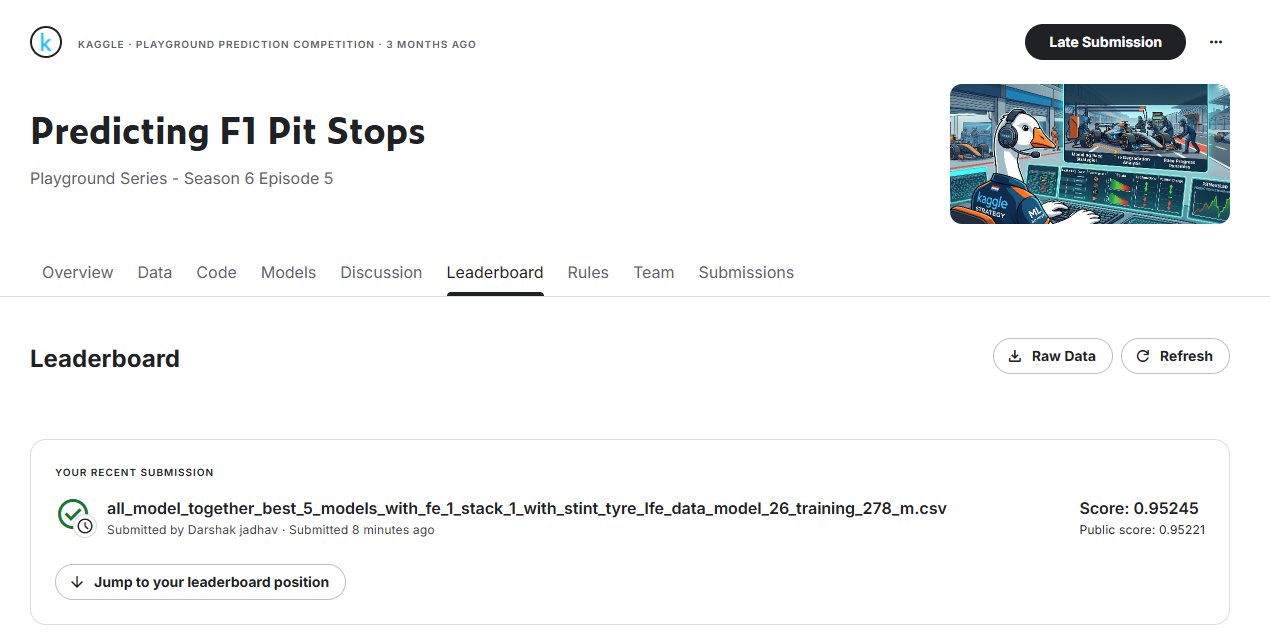